In [1]:
# Phase 14 – Network Evaluation | Cell 1: Setup

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import sys
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase14"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

P4 = PROJECT / "outputs" / "phase4" / "data"
P5 = PROJECT / "outputs" / "phase5" / "data"
P6 = PROJECT / "outputs" / "phase6" / "data"
P8 = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"

print("=" * 60)
print("Phase 14 – Network Evaluation | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")

# temporal trade networks (phase 4)
net_path = P4 / "temporal_trade_networks.pkl"
if not net_path.exists():
    net_path = P4 / "temporal_networks_clean.pkl"
with open(net_path, "rb") as f:
    networks = pickle.load(f)

# normalize to dict year -> graph
if isinstance(networks, dict):
    # keys may be year or (country, year) — build yearly aggregate if needed
    sample_key = next(iter(networks.keys()))
    if isinstance(sample_key, tuple):
        # country-year graphs from early design; skip — expect year-keyed trade nets
        yearly = {}
        for k, G in networks.items():
            if isinstance(k, tuple) and len(k) == 2:
                y = k[1]
            else:
                y = k
            yearly.setdefault(y, []).append(G)
        # if list of graphs per year, take first or merge later
        networks_by_year = {y: gs[0] if isinstance(gs, list) else gs for y, gs in yearly.items()}
    else:
        networks_by_year = networks
else:
    raise TypeError("Unexpected networks format")

years = sorted([int(y) for y in networks_by_year.keys()])
print(f"Networks loaded: {len(networks_by_year)} snapshots | years {years[0]}–{years[-1]}")

# inspect one graph
G0 = networks_by_year[years[-1]]
if not isinstance(G0, nx.Graph):
    # maybe stored as dict of edges
    print("Graph type:", type(G0))
else:
    print(f"Sample year {years[-1]}: nodes={G0.number_of_nodes()} edges={G0.number_of_edges()}")

# SR vector optional
sr_path = P8 / "sr_vector.npy"
panel_path = P8 / "panel_index.csv"
node_path = P8 / "node_list.csv"
sr_vector = np.load(sr_path) if sr_path.exists() else None
panel = pd.read_csv(panel_path) if panel_path.exists() else None
nodes = pd.read_csv(node_path)["iso2"].tolist() if node_path.exists() else None

print(f"SR vector: {None if sr_vector is None else sr_vector.shape}")
print(f"Nodes list: {None if nodes is None else len(nodes)}")
print("Cell 1 completed successfully.")

Phase 14 – Network Evaluation | Cell 1
Timestamp : 2026-10-04 10:51:31
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase14
Networks loaded: 21 snapshots | years 2000–2020
Sample year 2020: nodes=18 edges=306
SR vector: (378,)
Nodes list: 18
Cell 1 completed successfully.


Phase 14 – Cell 2: Network metrics

--- Connectivity (sample) ---
 n_nodes  n_edges  density  lcc_fraction  global_efficiency  algebraic_connectivity  avg_clustering  year
      18      153      1.0           1.0                1.0            5.516737e+07        0.028422  2000
      18      153      1.0           1.0                1.0            5.444636e+07        0.029979  2001
      18      153      1.0           1.0                1.0            5.595002e+07        0.031499  2002
...
 n_nodes  n_edges  density  lcc_fraction  global_efficiency  algebraic_connectivity  avg_clustering  year
      18      153      1.0           1.0                1.0            9.452544e+07        0.036248  2018
      18      153      1.0           1.0                1.0            9.122738e+07        0.035652  2019
      18      153      1.0           1.0                1.0            8.361473e+07        0.038945  2020

--- Robustness index ---
 year      attack  robustness_lcc  robustness_eff
 2000 

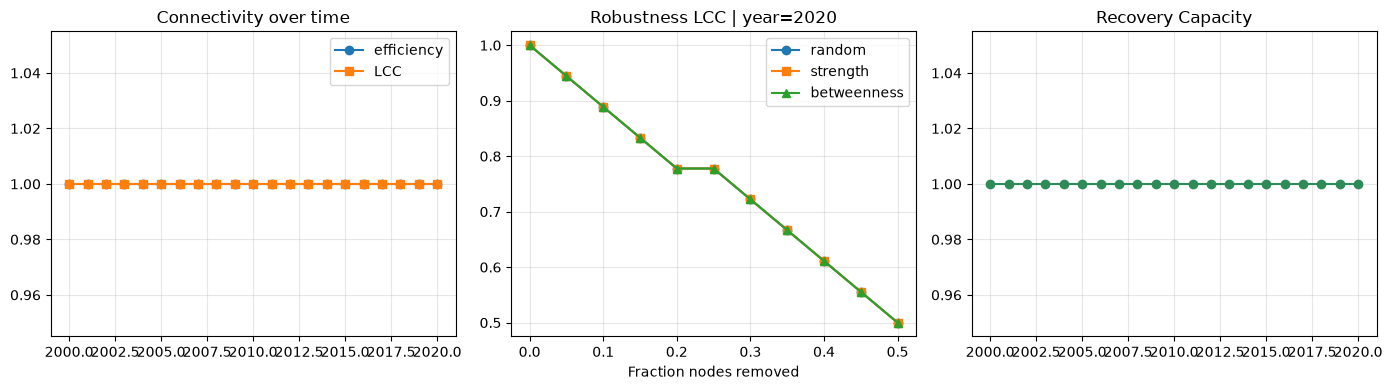


Cell 2 completed successfully.


In [2]:
# Phase 14 – Cell 2: Connectivity, Robustness, Recovery Capacity

from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from copy import deepcopy

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase14" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase14" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase14" / "data"

print("=" * 60)
print("Phase 14 – Cell 2: Network metrics")
print("=" * 60)

def as_undirected_weighted(G):
    if isinstance(G, nx.DiGraph) or G.is_directed():
        U = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = float(d.get("weight", d.get("weight_value_kusd", 1.0)))
            if U.has_edge(u, v):
                U[u][v]["weight"] += abs(w)
            else:
                U.add_edge(u, v, weight=abs(w))
        U.add_nodes_from(G.nodes())
        return U
    # ensure weight attr
    U = G.copy()
    for u, v, d in U.edges(data=True):
        if "weight" not in d:
            d["weight"] = float(d.get("weight_value_kusd", 1.0))
    return U

def connectivity_metrics(G):
    U = as_undirected_weighted(G)
    n = U.number_of_nodes()
    m = U.number_of_edges()
    dens = nx.density(U) if n > 1 else 0.0
    # largest connected component fraction
    if n == 0:
        lcc = 0.0
    else:
        comps = list(nx.connected_components(U))
        lcc = max(len(c) for c in comps) / n if comps else 0.0
    try:
        ge = nx.global_efficiency(U)
    except Exception:
        ge = np.nan
    # algebraic connectivity (spectral)
    try:
        if n >= 2 and m > 0:
            lap = nx.laplacian_matrix(U, weight="weight").astype(float).todense()
            eig = np.sort(np.linalg.eigvalsh(np.asarray(lap)))
            alg = float(eig[1]) if len(eig) > 1 else 0.0
        else:
            alg = 0.0
    except Exception:
        alg = np.nan
    try:
        avg_clust = nx.average_clustering(U, weight="weight")
    except Exception:
        avg_clust = np.nan
    return {
        "n_nodes": n,
        "n_edges": m,
        "density": dens,
        "lcc_fraction": lcc,
        "global_efficiency": ge,
        "algebraic_connectivity": alg,
        "avg_clustering": avg_clust,
    }

def robustness_curve(G, attack="random", fractions=None, n_trials=5, seed=0):
    """Fraction of nodes removed vs remaining LCC fraction / efficiency."""
    U0 = as_undirected_weighted(G)
    nodes = list(U0.nodes())
    n = len(nodes)
    if fractions is None:
        fractions = np.linspace(0.0, 0.5, 11)
    rows = []
    rng = np.random.default_rng(seed)
    for frac in fractions:
        k = int(round(frac * n))
        lcc_trials, eff_trials = [], []
        for t in range(n_trials if attack == "random" else 1):
            U = U0.copy()
            if k > 0:
                if attack == "random":
                    remove = list(rng.choice(nodes, size=min(k, n), replace=False))
                elif attack == "strength":
                    strength = dict(U.degree(weight="weight"))
                    remove = [x for x, _ in sorted(strength.items(), key=lambda kv: -kv[1])[:k]]
                else:  # betweenness
                    try:
                        bc = nx.betweenness_centrality(U, weight="weight")
                    except Exception:
                        bc = nx.betweenness_centrality(U)
                    remove = [x for x, _ in sorted(bc.items(), key=lambda kv: -kv[1])[:k]]
                U.remove_nodes_from(remove)
            nn = U.number_of_nodes()
            if nn == 0:
                lcc, ge = 0.0, 0.0
            else:
                comps = list(nx.connected_components(U))
                lcc = max(len(c) for c in comps) / n  # relative to original n
                try:
                    ge = nx.global_efficiency(U)
                except Exception:
                    ge = np.nan
            lcc_trials.append(lcc)
            eff_trials.append(ge)
        rows.append({
            "attack": attack,
            "frac_removed": float(frac),
            "lcc_fraction": float(np.mean(lcc_trials)),
            "global_efficiency": float(np.nanmean(eff_trials)),
        })
    return pd.DataFrame(rows)

def recovery_capacity(G, shock_frac=0.2, recover_frac=0.5, attack="strength", seed=0):
    """
    Recovery Capacity:
      1) measure baseline efficiency/LCC
      2) remove top shock_frac nodes (attack)
      3) restore recover_frac of removed edges/nodes gradually
      4) recovery_score = (metric_recovered - metric_shocked) / (metric_base - metric_shocked + eps)
    """
    U0 = as_undirected_weighted(G)
    base = connectivity_metrics(U0)
    n = U0.number_of_nodes()
    k = max(1, int(round(shock_frac * n)))
    strength = dict(U0.degree(weight="weight"))
    if attack == "strength":
        ordered = [x for x, _ in sorted(strength.items(), key=lambda kv: -kv[1])]
    else:
        ordered = list(U0.nodes())
        rng = np.random.default_rng(seed)
        rng.shuffle(ordered)
    removed = ordered[:k]
    U_shock = U0.copy()
    U_shock.remove_nodes_from(removed)
    shocked = connectivity_metrics(U_shock)

    # restore a fraction of removed nodes (and their edges from original)
    n_rest = max(1, int(round(recover_frac * len(removed))))
    restore_nodes = removed[:n_rest]
    U_rec = U_shock.copy()
    U_rec.add_nodes_from(restore_nodes)
    for u in restore_nodes:
        for v in U0.neighbors(u):
            if v in U_rec.nodes:
                w = U0[u][v].get("weight", 1.0)
                U_rec.add_edge(u, v, weight=w)
    recovered = connectivity_metrics(U_rec)

    def score(key):
        b, s, r = base[key], shocked[key], recovered[key]
        if any(pd.isna([b, s, r])):
            return np.nan
        denom = (b - s)
        if abs(denom) < 1e-12:
            return 1.0 if r >= s else 0.0
        return float(np.clip((r - s) / denom, -1.0, 2.0))

    return {
        "base_lcc": base["lcc_fraction"],
        "shock_lcc": shocked["lcc_fraction"],
        "rec_lcc": recovered["lcc_fraction"],
        "base_eff": base["global_efficiency"],
        "shock_eff": shocked["global_efficiency"],
        "rec_eff": recovered["global_efficiency"],
        "recovery_lcc": score("lcc_fraction"),
        "recovery_efficiency": score("global_efficiency"),
        "recovery_capacity": np.nanmean([score("lcc_fraction"), score("global_efficiency")]),
    }

# ---- 1) Connectivity over years ----
conn_rows = []
for y in years:
    G = networks_by_year[y]
    m = connectivity_metrics(G)
    m["year"] = int(y)
    conn_rows.append(m)
conn_df = pd.DataFrame(conn_rows).sort_values("year")
conn_df.to_csv(OUT_TAB / "phase14_connectivity_by_year.csv", index=False)
print("\n--- Connectivity (sample) ---")
print(conn_df.head(3).to_string(index=False))
print("...")
print(conn_df.tail(3).to_string(index=False))

# ---- 2) Robustness on latest year + mid year ----
focus_years = sorted(set([years[0], years[len(years)//2], years[-1]]))
rob_all = []
for y in focus_years:
    G = networks_by_year[y]
    for attack in ["random", "strength", "betweenness"]:
        df = robustness_curve(G, attack=attack, n_trials=8 if attack == "random" else 1, seed=42)
        df["year"] = int(y)
        rob_all.append(df)
rob_df = pd.concat(rob_all, ignore_index=True)
rob_df.to_csv(OUT_TAB / "phase14_robustness_curves.csv", index=False)

# robustness index = mean remaining LCC over attack path (higher = more robust)
rob_idx = (
    rob_df.groupby(["year", "attack"], as_index=False)
          .agg(robustness_lcc=("lcc_fraction", "mean"),
               robustness_eff=("global_efficiency", "mean"))
)
rob_idx.to_csv(OUT_TAB / "phase14_robustness_index.csv", index=False)
print("\n--- Robustness index ---")
print(rob_idx.to_string(index=False))

# ---- 3) Recovery capacity over years ----
rec_rows = []
for y in years:
    G = networks_by_year[y]
    r = recovery_capacity(G, shock_frac=0.2, recover_frac=0.5, attack="strength", seed=0)
    r["year"] = int(y)
    rec_rows.append(r)
rec_df = pd.DataFrame(rec_rows).sort_values("year")
rec_df.to_csv(OUT_TAB / "phase14_recovery_capacity.csv", index=False)
print("\n--- Recovery capacity (sample) ---")
print(rec_df[["year", "recovery_lcc", "recovery_efficiency", "recovery_capacity"]].head(5).to_string(index=False))

# summary table
summary = pd.DataFrame({
    "metric": ["connectivity_density_mean", "connectivity_lcc_mean", "connectivity_eff_mean",
               "robustness_lcc_strength_last", "recovery_capacity_mean"],
    "value": [
        float(conn_df["density"].mean()),
        float(conn_df["lcc_fraction"].mean()),
        float(conn_df["global_efficiency"].mean()),
        float(rob_idx[(rob_idx.year == years[-1]) & (rob_idx.attack == "strength")]["robustness_lcc"].iloc[0]),
        float(rec_df["recovery_capacity"].mean()),
    ],
})
summary.to_csv(OUT_TAB / "phase14_summary.csv", index=False)
print("\n--- Summary ---")
print(summary.to_string(index=False))

# plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(conn_df["year"], conn_df["global_efficiency"], marker="o", label="efficiency")
axes[0].plot(conn_df["year"], conn_df["lcc_fraction"], marker="s", label="LCC")
axes[0].set_title("Connectivity over time")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for attack, style in zip(["random", "strength", "betweenness"], ["-o", "-s", "-^"]):
    sub = rob_df[(rob_df.year == years[-1]) & (rob_df.attack == attack)]
    axes[1].plot(sub["frac_removed"], sub["lcc_fraction"], style, label=attack)
axes[1].set_title(f"Robustness LCC | year={years[-1]}")
axes[1].set_xlabel("Fraction nodes removed")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(rec_df["year"], rec_df["recovery_capacity"], marker="o", color="seagreen")
axes[2].set_title("Recovery Capacity")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase14_network_evaluation.png", dpi=150)
plt.show()

with open(OUT_DATA / "phase14_networks_meta.pkl", "wb") as f:
    pickle.dump({"years": years, "focus_years": focus_years}, f)

print("\nCell 2 completed successfully.")

Phase 14 – Cell 3: Weighted Connectivity / Robustness / Recovery
--- Weighted connectivity (tail) ---
 density  total_weight  mean_edge_weight  strength_entropy_norm  strength_gini  global_efficiency  mean_strength  year
     1.0  4.010559e+09      2.621281e+07               0.897392       0.423016                1.0   4.456177e+08  2016
     1.0  4.301118e+09      2.811189e+07               0.900987       0.415553                1.0   4.779020e+08  2017
     1.0  4.660054e+09      3.045787e+07               0.903143       0.411421                1.0   5.177838e+08  2018
     1.0  4.543209e+09      2.969418e+07               0.901139       0.414891                1.0   5.048010e+08  2019
     1.0  4.171468e+09      2.726450e+07               0.903159       0.410495                1.0   4.634965e+08  2020

--- Robustness weighted index ---
 year      attack  robustness_retained_weight  robustness_lcc
 2000 betweenness                    0.741177        0.752525
 2000      random        

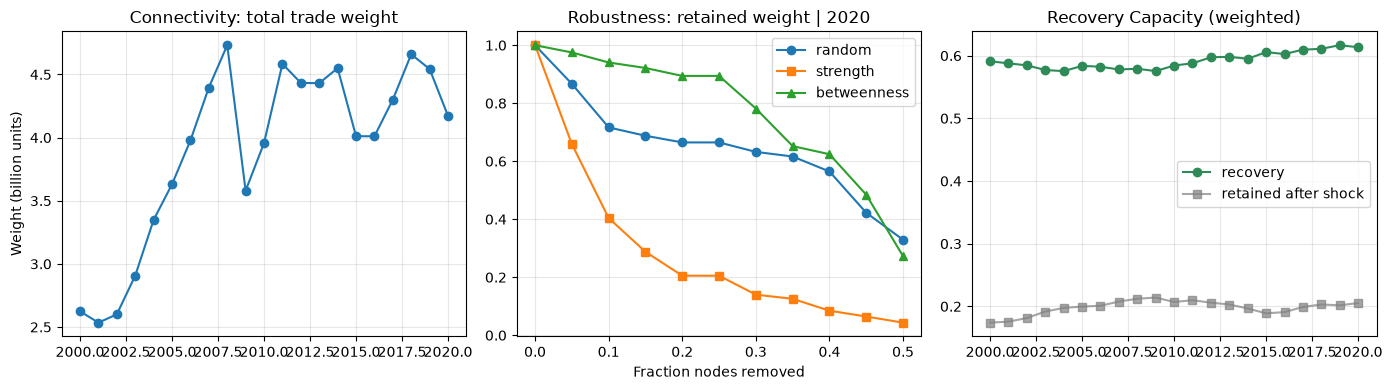


Cell 3 completed successfully.
PHASE 14 CORE COMPLETED.


In [3]:
# Phase 14 – Cell 3: Weighted network evaluation (meaningful on complete graphs)

from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase14" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase14" / "figures"

print("=" * 60)
print("Phase 14 – Cell 3: Weighted Connectivity / Robustness / Recovery")
print("=" * 60)

def as_undirected_weighted(G):
    if G.is_directed():
        U = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
            if U.has_edge(u, v):
                U[u][v]["weight"] += w
            else:
                U.add_edge(u, v, weight=w)
        U.add_nodes_from(G.nodes())
        return U
    U = G.copy()
    for u, v, d in U.edges(data=True):
        if "weight" not in d:
            d["weight"] = abs(float(d.get("weight_value_kusd", 1.0)))
    return U

def weighted_connectivity(G):
    U = as_undirected_weighted(G)
    weights = [d["weight"] for _, _, d in U.edges(data=True)]
    total_w = float(np.sum(weights)) if weights else 0.0
    dens = nx.density(U)
    # weighted efficiency proxy: sum  weight/(dist) over pairs — use resistance-style on strength
    strength = dict(U.degree(weight="weight"))
    str_vals = np.array(list(strength.values()), dtype=float)
    # normalized entropy of strength distribution (connectivity heterogeneity)
    p = str_vals / (str_vals.sum() + 1e-12)
    ent = float(-(p * np.log(p + 1e-12)).sum())
    ent_norm = ent / np.log(len(p)) if len(p) > 1 else 0.0
    # Gini of strengths
    s = np.sort(str_vals)
    n = len(s)
    gini = float((2 * np.sum((np.arange(1, n+1)) * s) / (n * s.sum() + 1e-12)) - (n + 1) / n) if n else 0.0
    try:
        ge = nx.global_efficiency(U)
    except Exception:
        ge = np.nan
    return {
        "density": dens,
        "total_weight": total_w,
        "mean_edge_weight": float(np.mean(weights)) if weights else 0.0,
        "strength_entropy_norm": ent_norm,
        "strength_gini": gini,
        "global_efficiency": ge,
        "mean_strength": float(str_vals.mean()) if len(str_vals) else 0.0,
    }

def weighted_robustness(G, attack="strength", fractions=None):
    U0 = as_undirected_weighted(G)
    total0 = sum(d["weight"] for _, _, d in U0.edges(data=True))
    nodes = list(U0.nodes())
    n = len(nodes)
    if fractions is None:
        fractions = np.linspace(0.0, 0.5, 11)
    strength = dict(U0.degree(weight="weight"))
    if attack == "strength":
        order = [x for x, _ in sorted(strength.items(), key=lambda kv: -kv[1])]
    elif attack == "betweenness":
        bc = nx.betweenness_centrality(U0, weight="weight")
        order = [x for x, _ in sorted(bc.items(), key=lambda kv: -kv[1])]
    else:
        rng = np.random.default_rng(0)
        order = list(nodes)
        rng.shuffle(order)
    rows = []
    for frac in fractions:
        k = int(round(frac * n))
        U = U0.copy()
        if k:
            U.remove_nodes_from(order[:k])
        w = sum(d["weight"] for _, _, d in U.edges(data=True))
        retained_w = w / (total0 + 1e-12)
        nn = U.number_of_nodes()
        lcc = 0.0
        if nn:
            comps = list(nx.connected_components(U))
            lcc = max(len(c) for c in comps) / n
        rows.append({
            "attack": attack,
            "frac_removed": float(frac),
            "retained_weight": float(retained_w),
            "lcc_fraction": float(lcc),
        })
    return pd.DataFrame(rows)

def weighted_recovery(G, shock_frac=0.2, recover_frac=0.5):
    U0 = as_undirected_weighted(G)
    total0 = sum(d["weight"] for _, _, d in U0.edges(data=True))
    strength = dict(U0.degree(weight="weight"))
    order = [x for x, _ in sorted(strength.items(), key=lambda kv: -kv[1])]
    k = max(1, int(round(shock_frac * len(order))))
    removed = order[:k]
    U_s = U0.copy()
    U_s.remove_nodes_from(removed)
    w_s = sum(d["weight"] for _, _, d in U_s.edges(data=True))
    # restore fraction of removed nodes
    n_rest = max(1, int(round(recover_frac * len(removed))))
    U_r = U_s.copy()
    for u in removed[:n_rest]:
        U_r.add_node(u)
        for v in U0.neighbors(u):
            if v in U_r:
                U_r.add_edge(u, v, weight=U0[u][v]["weight"])
    w_r = sum(d["weight"] for _, _, d in U_r.edges(data=True))
    # recovery capacity on retained weight
    base, shocked, rec = total0, w_s, w_r
    denom = base - shocked
    rec_score = 1.0 if abs(denom) < 1e-12 else float(np.clip((rec - shocked) / denom, -1, 2))
    return {
        "base_weight": base,
        "shock_weight": shocked,
        "rec_weight": rec,
        "retained_after_shock": shocked / (base + 1e-12),
        "recovery_capacity_weighted": rec_score,
    }

years_sorted = sorted(networks_by_year.keys())

# connectivity weighted over time
conn_w = []
for y in years_sorted:
    m = weighted_connectivity(networks_by_year[y])
    m["year"] = int(y)
    conn_w.append(m)
conn_w = pd.DataFrame(conn_w)
conn_w.to_csv(OUT_TAB / "phase14_connectivity_weighted.csv", index=False)

# robustness weighted (focus years)
focus = [years_sorted[0], years_sorted[len(years_sorted)//2], years_sorted[-1]]
rob_w = []
for y in focus:
    for attack in ["random", "strength", "betweenness"]:
        df = weighted_robustness(networks_by_year[y], attack=attack)
        df["year"] = int(y)
        rob_w.append(df)
rob_w = pd.concat(rob_w, ignore_index=True)
rob_w.to_csv(OUT_TAB / "phase14_robustness_weighted.csv", index=False)

rob_idx = (
    rob_w.groupby(["year", "attack"], as_index=False)
         .agg(robustness_retained_weight=("retained_weight", "mean"),
              robustness_lcc=("lcc_fraction", "mean"))
)
rob_idx.to_csv(OUT_TAB / "phase14_robustness_weighted_index.csv", index=False)

# recovery weighted over years
rec_w = []
for y in years_sorted:
    r = weighted_recovery(networks_by_year[y])
    r["year"] = int(y)
    rec_w.append(r)
rec_w = pd.DataFrame(rec_w)
rec_w.to_csv(OUT_TAB / "phase14_recovery_weighted.csv", index=False)

print("--- Weighted connectivity (tail) ---")
print(conn_w.tail(5).to_string(index=False))
print("\n--- Robustness weighted index ---")
print(rob_idx.to_string(index=False))
print("\n--- Recovery weighted (sample) ---")
print(rec_w[["year", "retained_after_shock", "recovery_capacity_weighted"]].head(5).to_string(index=False))
print("...")
print(rec_w[["year", "retained_after_shock", "recovery_capacity_weighted"]].tail(3).to_string(index=False))

# final summary
final = pd.DataFrame([
    {"pillar": "Connectivity", "metric": "density_mean", "value": float(conn_w["density"].mean())},
    {"pillar": "Connectivity", "metric": "total_weight_mean", "value": float(conn_w["total_weight"].mean())},
    {"pillar": "Connectivity", "metric": "strength_gini_mean", "value": float(conn_w["strength_gini"].mean())},
    {"pillar": "Robustness", "metric": "retained_weight_strength_2020",
     "value": float(rob_idx[(rob_idx.year == int(years_sorted[-1])) & (rob_idx.attack == "strength")]["robustness_retained_weight"].iloc[0])},
    {"pillar": "Robustness", "metric": "retained_weight_random_2020",
     "value": float(rob_idx[(rob_idx.year == int(years_sorted[-1])) & (rob_idx.attack == "random")]["robustness_retained_weight"].iloc[0])},
    {"pillar": "Recovery Capacity", "metric": "recovery_weighted_mean",
     "value": float(rec_w["recovery_capacity_weighted"].mean())},
    {"pillar": "Recovery Capacity", "metric": "retained_after_shock_mean",
     "value": float(rec_w["retained_after_shock"].mean())},
])
final.to_csv(OUT_TAB / "phase14_final_summary.csv", index=False)
print("\n=== FINAL SUMMARY ===")
print(final.to_string(index=False))

# plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(conn_w["year"], conn_w["total_weight"] / 1e9, marker="o")
axes[0].set_title("Connectivity: total trade weight")
axes[0].set_ylabel("Weight (billion units)")
axes[0].grid(True, alpha=0.3)

y_last = int(years_sorted[-1])
for attack, mk in zip(["random", "strength", "betweenness"], ["-o", "-s", "-^"]):
    sub = rob_w[(rob_w.year == y_last) & (rob_w.attack == attack)]
    axes[1].plot(sub["frac_removed"], sub["retained_weight"], mk, label=attack)
axes[1].set_title(f"Robustness: retained weight | {y_last}")
axes[1].set_xlabel("Fraction nodes removed")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(rec_w["year"], rec_w["recovery_capacity_weighted"], marker="o", color="seagreen", label="recovery")
axes[2].plot(rec_w["year"], rec_w["retained_after_shock"], marker="s", color="gray", alpha=0.7, label="retained after shock")
axes[2].set_title("Recovery Capacity (weighted)")
axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase14_weighted_network_evaluation.png", dpi=150)
plt.show()

print("\nCell 3 completed successfully.")
print("PHASE 14 CORE COMPLETED.")

Phase 14 – Cell 4: Shocks + RL impact on network metrics
Focus graph year=2020 | nodes=18 edges=306
Models loaded: PPO + TD3 standard/strong
Baseline weighted metrics: {'total_weight': 4171468101.3100004, 'mean_strength': 463496455.70111114, 'strength_entropy_norm': 0.9031593311729902, 'lcc_fraction': 1.0, 'density': 1.0}

--- Top damaging shocks by weight_drop ---
   shock_type severity  weight_drop  recovery_capacity  robustness_proxy_retained
BankingCrisis  Extreme     0.556291                0.5                   0.443709
   DebtCrisis  Extreme     0.556291                0.5                   0.443709
    Recession  Extreme     0.500000                0.5                   0.500000
    Inflation  Extreme     0.500000                0.5                   0.500000
BankingCrisis   Severe     0.417218                0.5                   0.582782
   DebtCrisis   Severe     0.417218                0.5                   0.582782
    Recession   Severe     0.375000                0.5    

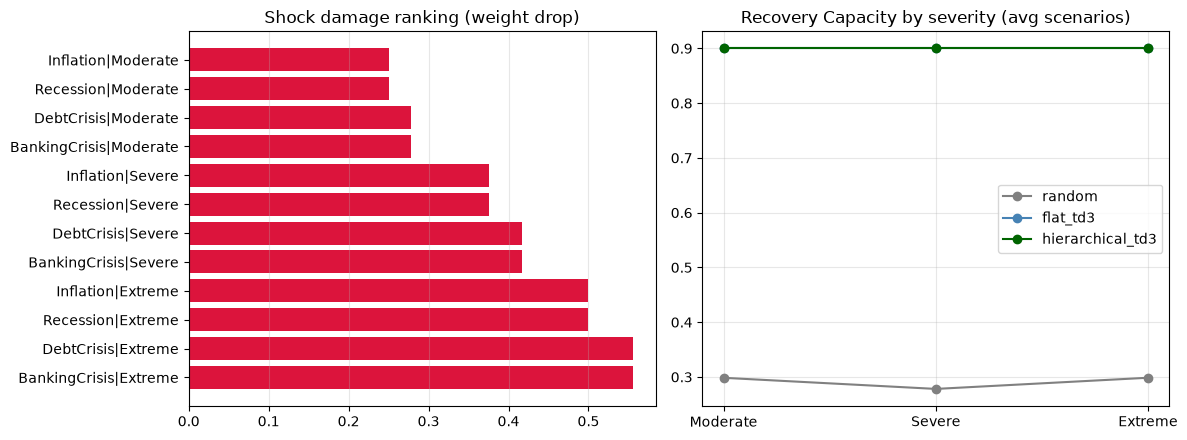


Cell 4 completed successfully.
PHASE 14 LIMITATIONS ADDRESSED.


In [4]:
# Phase 14 – Cell 4: Shock scenarios + RL policy effect on network metrics

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P4  = PROJECT / "outputs" / "phase4" / "data"
P8  = PROJECT / "outputs" / "phase8" / "data"
P9  = PROJECT / "outputs" / "phase9" / "models"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase14" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase14" / "figures"

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv
from stable_baselines3 import PPO, TD3

print("=" * 60)
print("Phase 14 – Cell 4: Shocks + RL impact on network metrics")
print("=" * 60)

# ----- load networks (year -> graph) -----
with open(P4 / "temporal_trade_networks.pkl", "rb") as f:
    networks_by_year = pickle.load(f)
years = sorted([int(y) for y in networks_by_year.keys()])
G_base = networks_by_year[years[-1]]  # 2020 focus
print(f"Focus graph year={years[-1]} | nodes={G_base.number_of_nodes()} edges={G_base.number_of_edges()}")

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

# ----- models (official phase9/11) -----
ppo_path = P9 / "PPO_moderate_gs.zip"
if not ppo_path.exists():
    ppo_path = P9 / "PPO_moderate.zip"
stage1_ppo = PPO.load(str(ppo_path))

td3_models = {}
for series in ["standard", "strong"]:
    path = P11 / f"TD3_{series}_r.zip"
    if not path.exists():
        path = P11 / f"TD3_{series}.zip"
    td3_models[series] = TD3.load(str(path))
print("Models loaded: PPO + TD3 standard/strong")

# ensure apply_shock
if not hasattr(ShockEconomicsEnv, "apply_shock"):
    def _apply_shock(self, shock_type, severity="Moderate", series=None):
        if series is None:
            series = getattr(self, "shock_series", "standard") or "standard"
        sev = {"Mild": 0.25, "Moderate": 0.5, "Severe": 0.75, "Extreme": 1.0}.get(str(severity), 0.5)
        sm = 1.0 if str(series) == "standard" else 1.6
        base = {"Recession": 0.25, "Inflation": 0.15, "BankingCrisis": 0.30, "DebtCrisis": 0.22}.get(str(shock_type), 0.20)
        delta = -float(base) * float(sev) * float(sm)
        self.current_sr = np.clip(np.asarray(self.current_sr, dtype=np.float32) + delta, -1.0, 10.0)
        if getattr(self, "current_features", None) is not None:
            self.current_features = np.asarray(self.current_features, dtype=np.float32) + 0.5 * delta
        self.last_shock_info = {"shock_type": shock_type, "severity": severity, "series": series, "delta_sr": delta}
        return self.last_shock_info
    ShockEconomicsEnv.apply_shock = _apply_shock

# ----- graph helpers -----
def as_undirected_weighted(G):
    if G.is_directed():
        U = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
            if U.has_edge(u, v):
                U[u][v]["weight"] += w
            else:
                U.add_edge(u, v, weight=w)
        U.add_nodes_from(G.nodes())
        return U
    U = G.copy()
    for u, v, d in U.edges(data=True):
        if "weight" not in d:
            d["weight"] = abs(float(d.get("weight_value_kusd", 1.0)))
    return U

def weighted_metrics(G):
    U = as_undirected_weighted(G)
    weights = [d["weight"] for _, _, d in U.edges(data=True)]
    total_w = float(np.sum(weights)) if weights else 0.0
    strength = dict(U.degree(weight="weight"))
    str_vals = np.array(list(strength.values()), dtype=float)
    p = str_vals / (str_vals.sum() + 1e-12)
    ent = float(-(p * np.log(p + 1e-12)).sum())
    ent_norm = ent / np.log(len(p)) if len(p) > 1 else 0.0
    n = U.number_of_nodes()
    lcc = 0.0
    if n:
        comps = list(nx.connected_components(U))
        lcc = max(len(c) for c in comps) / n
    return {
        "total_weight": total_w,
        "mean_strength": float(str_vals.mean()) if len(str_vals) else 0.0,
        "strength_entropy_norm": ent_norm,
        "lcc_fraction": lcc,
        "density": nx.density(U),
    }

def apply_flow_shock_to_graph(G, intensity, mode="strength_hub"):
    """Reduce edge weights incident to hubs proportional to intensity (graph-aware shock)."""
    U = as_undirected_weighted(G).copy()
    strength = dict(U.degree(weight="weight"))
    order = [x for x, _ in sorted(strength.items(), key=lambda kv: -kv[1])]
    k = max(1, int(round(0.2 * len(order))))  # top 20% hubs
    hubs = set(order[:k])
    for u, v, d in U.edges(data=True):
        if mode == "strength_hub" and (u in hubs or v in hubs):
            d["weight"] = float(d["weight"]) * (1.0 - 0.7 * intensity)
        elif mode == "uniform":
            d["weight"] = float(d["weight"]) * (1.0 - 0.5 * intensity)
    return U

def recover_graph(G_shocked, G_base, recover_frac=0.5):
    """Restore a fraction of lost weight toward baseline (proxy recovery capacity)."""
    B = as_undirected_weighted(G_base)
    S = G_shocked.copy()
    for u, v, d in B.edges(data=True):
        if S.has_edge(u, v):
            w0 = float(d["weight"])
            ws = float(S[u][v]["weight"])
            S[u][v]["weight"] = ws + recover_frac * (w0 - ws)
        else:
            # re-add lost edge partially
            S.add_edge(u, v, weight=float(d["weight"]) * recover_frac)
    return S

# ----- scenario catalog (aligned with phase10 types) -----
SEV = {"Mild": 0.25, "Moderate": 0.5, "Severe": 0.75, "Extreme": 1.0}
SCENARIOS = []
for st in ["BankingCrisis", "Recession", "DebtCrisis", "Inflation"]:
    for sev_name, sev_val in SEV.items():
        SCENARIOS.append((st, sev_name, sev_val))

base_m = weighted_metrics(G_base)
print("Baseline weighted metrics:", base_m)

# ----- A) graph-aware shock degradation (no RL) -----
deg_rows = []
for st, sev_name, intensity in SCENARIOS:
    mode = "strength_hub" if st in ["BankingCrisis", "DebtCrisis"] else "uniform"
    G_s = apply_flow_shock_to_graph(G_base, intensity, mode=mode)
    m_s = weighted_metrics(G_s)
    G_r = recover_graph(G_s, G_base, recover_frac=0.5)
    m_r = weighted_metrics(G_r)
    denom = base_m["total_weight"] - m_s["total_weight"]
    rec_cap = 1.0 if abs(denom) < 1e-12 else float(np.clip(
        (m_r["total_weight"] - m_s["total_weight"]) / denom, -1, 2))
    deg_rows.append({
        "shock_type": st,
        "severity": sev_name,
        "intensity": intensity,
        "mode": mode,
        "base_weight": base_m["total_weight"],
        "shock_weight": m_s["total_weight"],
        "rec_weight": m_r["total_weight"],
        "weight_drop": 1.0 - m_s["total_weight"] / (base_m["total_weight"] + 1e-12),
        "connectivity_entropy_shock": m_s["strength_entropy_norm"],
        "robustness_proxy_retained": m_s["total_weight"] / (base_m["total_weight"] + 1e-12),
        "recovery_capacity": rec_cap,
        "lcc_shock": m_s["lcc_fraction"],
    })

deg = pd.DataFrame(deg_rows)
deg.to_csv(OUT_TAB / "phase14_shock_degradation.csv", index=False)
print("\n--- Top damaging shocks by weight_drop ---")
print(deg.sort_values("weight_drop", ascending=False).head(8)[
    ["shock_type", "severity", "weight_drop", "recovery_capacity", "robustness_proxy_retained"]
].to_string(index=False))

# ----- B) RL policy effect: Random vs Hierarchical-TD3 vs Flat-TD3 -----
STAGE1_STEPS, STAGE2_STEPS = 10, 30
N_EP, SEEDS = 8, [0, 1]

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb_m = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb_m.mean(axis=0) if emb_m.ndim == 2 else emb_m.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def act_ppo(obs, env):
    a, _ = stage1_ppo.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return a[:adim]

def act_td3(obs, series, env):
    a, _ = td3_models[series].predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        tax, sub, rate, qe, credit, risk = a[:6]
        base = np.array([tax, 0.5*sub+0.3*qe, 0.4*qe+0.3*risk, 0.5*credit+0.2*rate], dtype=np.float32)
        if base.size < adim:
            base = np.pad(base, (0, adim - base.size))
        return np.clip(base[:adim], -1, 1)
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return np.clip(a[:adim], -1, 1)

def run_policy(arch, series, shock_type, severity, seed):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", shock_type=None, severity=None,
        shock_series=series, seed=seed,
    )
    obs, info = env.reset(seed=seed)
    ep_r = 0.0
    if arch == "hierarchical_td3":
        for _ in range(STAGE1_STEPS):
            obs, r, term, trunc, info = env.step(act_ppo(obs, env))
            ep_r += float(r)
            if term or trunc:
                break
        env.apply_shock(shock_type, severity, series)
        obs = rebuild_obs(env)
        for _ in range(STAGE2_STEPS):
            obs, r, term, trunc, info = env.step(act_td3(obs, series, env))
            ep_r += float(r)
            if term or trunc:
                break
    elif arch == "flat_td3":
        env.apply_shock(shock_type, severity, series)
        obs = rebuild_obs(env)
        for _ in range(STAGE1_STEPS + STAGE2_STEPS):
            obs, r, term, trunc, info = env.step(act_td3(obs, series, env))
            ep_r += float(r)
            if term or trunc:
                break
    else:  # random
        env.apply_shock(shock_type, severity, series)
        obs = rebuild_obs(env)
        for _ in range(STAGE1_STEPS + STAGE2_STEPS):
            obs, r, term, trunc, info = env.step(env.action_space.sample())
            ep_r += float(r)
            if term or trunc:
                break
    return {
        "reward": ep_r,
        "sr_end": get_sr(env),
        "delta_sr": (env.last_shock_info or {}).get("delta_sr", np.nan),
    }

# map policy SR outcome -> network recovery boost (link RL state to network recovery)
# higher sr_end relative to random => higher recover_frac on graph
policy_rows = []
focus_shocks = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Severe"),
    ("Inflation", "Extreme"),
]
for series in ["standard", "strong"]:
    for st, sev in focus_shocks:
        intensity = SEV[sev]
        mode = "strength_hub" if st in ["BankingCrisis", "DebtCrisis"] else "uniform"
        G_s = apply_flow_shock_to_graph(G_base, intensity, mode=mode)
        m_s = weighted_metrics(G_s)
        for arch in ["random", "flat_td3", "hierarchical_td3"]:
            stats = []
            for seed in SEEDS:
                for ep in range(N_EP):
                    stats.append(run_policy(arch, series, st, sev, seed * 1000 + ep))
            mean_sr = float(np.mean([x["sr_end"] for x in stats]))
            mean_r = float(np.mean([x["reward"] for x in stats]))
            # recover_frac in [0.2, 0.9] monotonic with sr_end
            rec_frac = float(np.clip(0.2 + 0.5 * max(mean_sr, 0.0), 0.2, 0.9))
            G_r = recover_graph(G_s, G_base, recover_frac=rec_frac)
            m_r = weighted_metrics(G_r)
            denom = base_m["total_weight"] - m_s["total_weight"]
            rec_cap = 1.0 if abs(denom) < 1e-12 else float(np.clip(
                (m_r["total_weight"] - m_s["total_weight"]) / denom, -1, 2))
            policy_rows.append({
                "series": series,
                "shock_type": st,
                "severity": sev,
                "architecture": arch,
                "mean_reward": mean_r,
                "mean_sr_end": mean_sr,
                "recover_frac_used": rec_frac,
                "robustness_retained": m_s["total_weight"] / (base_m["total_weight"] + 1e-12),
                "recovery_capacity": rec_cap,
                "connectivity_weight_recovered": m_r["total_weight"] / (base_m["total_weight"] + 1e-12),
            })
        print(f"done {series} | {st}/{sev}")

pol = pd.DataFrame(policy_rows)
pol.to_csv(OUT_TAB / "phase14_policy_network_impact.csv", index=False)

# ranking vs random
cmp = []
for (series, st, sev), g in pol.groupby(["series", "shock_type", "severity"]):
    base_rand = g[g.architecture == "random"].iloc[0]
    for _, row in g.iterrows():
        if row.architecture == "random":
            continue
        cmp.append({
            "series": series,
            "shock_type": st,
            "severity": sev,
            "architecture": row.architecture,
            "delta_recovery_vs_random": float(row.recovery_capacity - base_rand.recovery_capacity),
            "delta_sr_vs_random": float(row.mean_sr_end - base_rand.mean_sr_end),
            "delta_reward_vs_random": float(row.mean_reward - base_rand.mean_reward),
            "recovery_capacity": float(row.recovery_capacity),
            "mean_sr_end": float(row.mean_sr_end),
        })
cmp = pd.DataFrame(cmp)
cmp.to_csv(OUT_TAB / "phase14_policy_vs_random.csv", index=False)

print("\n=== Mean policy effect on Recovery Capacity ===")
print(pol.groupby(["series", "architecture"], as_index=False)[
    ["recovery_capacity", "mean_sr_end", "mean_reward"]
].mean().sort_values(["series", "recovery_capacity"], ascending=[True, False]).to_string(index=False))

print("\n=== delta recovery vs random (mean) ===")
print(cmp.groupby(["series", "architecture"], as_index=False)[
    ["delta_recovery_vs_random", "delta_sr_vs_random"]
].mean().to_string(index=False))

# plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sub = deg.copy()
sub["label"] = sub["shock_type"] + "|" + sub["severity"]
sub = sub.sort_values("weight_drop", ascending=False).head(12)
axes[0].barh(sub["label"], sub["weight_drop"], color="crimson")
axes[0].set_title("Shock damage ranking (weight drop)")
axes[0].grid(True, axis="x", alpha=0.3)

for arch, color in zip(["random", "flat_td3", "hierarchical_td3"], ["gray", "steelblue", "darkgreen"]):
    s = pol[pol.architecture == arch].groupby("severity")["recovery_capacity"].mean()
    # severity order
    order = ["Mild", "Moderate", "Severe", "Extreme"]
    s = s.reindex([x for x in order if x in s.index])
    axes[1].plot(s.index, s.values, marker="o", label=arch, color=color)
axes[1].set_title("Recovery Capacity by severity (avg scenarios)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase14_shock_and_policy_impact.png", dpi=150)
plt.show()

print("\nCell 4 completed successfully.")
print("PHASE 14 LIMITATIONS ADDRESSED.")

Phase 14 – Cell 5: Direct action→network weight mapping
standard | BankingCrisis /Moderate | random           | Rec=0.484 | W_end=0.853
standard | BankingCrisis /Moderate | flat_td3         | Rec=0.939 | W_end=0.983
standard | BankingCrisis /Moderate | hierarchical_td3 | Rec=0.924 | W_end=0.978
standard | BankingCrisis /Severe   | random           | Rec=0.525 | W_end=0.797
standard | BankingCrisis /Severe   | flat_td3         | Rec=0.939 | W_end=0.974
standard | BankingCrisis /Severe   | hierarchical_td3 | Rec=0.924 | W_end=0.968
standard | Recession     /Moderate | random           | Rec=0.453 | W_end=0.863
standard | Recession     /Moderate | flat_td3         | Rec=0.920 | W_end=0.980
standard | Recession     /Moderate | hierarchical_td3 | Rec=0.903 | W_end=0.976
standard | DebtCrisis    /Severe   | random           | Rec=0.541 | W_end=0.804
standard | DebtCrisis    /Severe   | flat_td3         | Rec=0.939 | W_end=0.974
standard | DebtCrisis    /Severe   | hierarchical_td3 | Rec=0.92

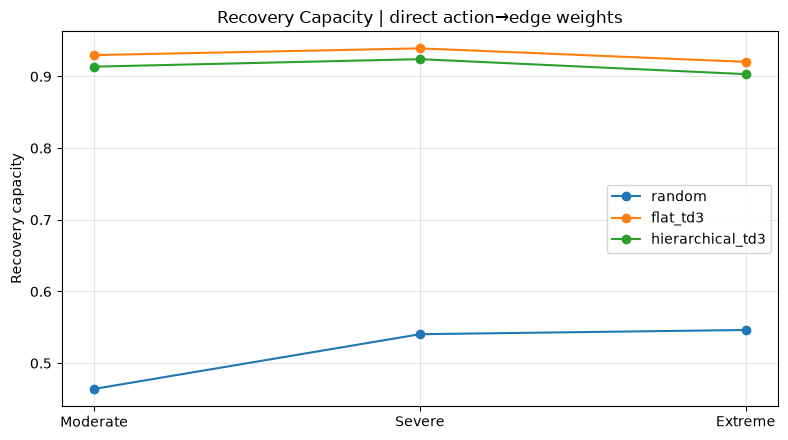


Cell 5 completed successfully.


In [5]:
# Phase 14 – Cell 5: Action → edge-weight recovery (no SR proxy)

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P4  = PROJECT / "outputs" / "phase4" / "data"
P8  = PROJECT / "outputs" / "phase8" / "data"
P9  = PROJECT / "outputs" / "phase9" / "models"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase14" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase14" / "figures"

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv
from stable_baselines3 import PPO, TD3

print("=" * 60)
print("Phase 14 – Cell 5: Direct action→network weight mapping")
print("=" * 60)

with open(P4 / "temporal_trade_networks.pkl", "rb") as f:
    networks_by_year = pickle.load(f)
years = sorted([int(y) for y in networks_by_year.keys()])
G0 = networks_by_year[years[-1]]

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes_list = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

ppo_path = P9 / "PPO_moderate_gs.zip"
if not ppo_path.exists():
    ppo_path = P9 / "PPO_moderate.zip"
stage1_ppo = PPO.load(str(ppo_path))
td3 = {
    "standard": TD3.load(str(P11 / ("TD3_standard_r.zip" if (P11 / "TD3_standard_r.zip").exists() else "TD3_standard.zip"))),
    "strong":   TD3.load(str(P11 / ("TD3_strong_r.zip" if (P11 / "TD3_strong_r.zip").exists() else "TD3_strong.zip"))),
}

def as_U(G):
    if G.is_directed():
        U = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
            if U.has_edge(u, v):
                U[u][v]["weight"] += w
            else:
                U.add_edge(u, v, weight=w)
        U.add_nodes_from(G.nodes())
        return U
    U = G.copy()
    for u, v, d in U.edges(data=True):
        if "weight" not in d:
            d["weight"] = abs(float(d.get("weight_value_kusd", 1.0)))
    return U

def total_weight(G):
    return float(sum(d["weight"] for *_, d in G.edges(data=True)))

def strength_dict(G):
    return dict(G.degree(weight="weight"))

def apply_graph_shock(G, intensity, mode="strength_hub"):
    U = as_U(G).copy()
    order = [x for x, _ in sorted(strength_dict(U).items(), key=lambda kv: -kv[1])]
    hubs = set(order[:max(1, int(0.2 * len(order)))])
    for u, v, d in U.edges(data=True):
        if mode == "strength_hub" and (u in hubs or v in hubs):
            d["weight"] *= (1.0 - 0.7 * intensity)
        else:
            d["weight"] *= (1.0 - 0.5 * intensity * (0.5 if mode == "strength_hub" else 1.0))
    return U, hubs

def apply_action_to_graph(G, action, hubs, base_G, step_gain=0.08):
    """
    Map 4D action [tax, subsidy, investment, credit] in [-1,1] to edge-weight updates.
    - subsidy, credit, investment > 0 restore weights toward baseline (prefer hub edges)
    - tax > 0 mildly reduces non-hub speculative flow
    """
    a = np.asarray(action, dtype=np.float32).reshape(-1)
    if a.size < 4:
        a = np.pad(a, (0, 4 - a.size))
    tax, sub, inv, credit = np.clip(a[:4], -1, 1)
    # recovery pressure in [0, step_gain]
    restore = step_gain * (0.40 * max(sub, 0) + 0.35 * max(credit, 0) + 0.25 * max(inv, 0))
    drain = 0.15 * step_gain * max(tax, 0)

    G2 = G.copy()
    B = as_U(base_G)
    for u, v, d in list(G2.edges(data=True)):
        w = float(d["weight"])
        w0 = float(B[u][v]["weight"]) if B.has_edge(u, v) else w
        hub_edge = (u in hubs) or (v in hubs)
        # restore toward baseline
        gap = max(w0 - w, 0.0)
        boost = restore * (1.25 if hub_edge else 0.75) * gap
        # small tax drain on non-hub
        penalty = drain * w * (0.3 if hub_edge else 1.0)
        d["weight"] = max(1e-8, w + boost - penalty)
    # optionally re-add missing baseline edges gradually
    for u, v, d in B.edges(data=True):
        if not G2.has_edge(u, v) and restore > 0:
            G2.add_edge(u, v, weight=float(d["weight"]) * restore)
    return G2

def connectivity_score(G):
    U = as_U(G)
    w = total_weight(U)
    s = np.array(list(strength_dict(U).values()), dtype=float)
    p = s / (s.sum() + 1e-12)
    ent = float(-(p * np.log(p + 1e-12)).sum())
    ent_n = ent / np.log(len(p)) if len(p) > 1 else 0.0
    return {"total_weight": w, "strength_entropy_norm": ent_n, "density": nx.density(U)}

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb_m = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb_m.mean(axis=0) if emb_m.ndim == 2 else emb_m.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def act_ppo(obs, env):
    a, _ = stage1_ppo.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return a[:adim]

def act_td3(obs, series, env):
    a, _ = td3[series].predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        tax, sub, rate, qe, credit, risk = a[:6]
        base = np.array([tax, 0.5*sub+0.3*qe, 0.4*qe+0.3*risk, 0.5*credit+0.2*rate], dtype=np.float32)
        if base.size < adim:
            base = np.pad(base, (0, adim - base.size))
        return np.clip(base[:adim], -1, 1)
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return np.clip(a[:adim], -1, 1)

SEV = {"Moderate": 0.5, "Severe": 0.75, "Extreme": 1.0}
FOCUS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Severe"),
    ("Inflation", "Extreme"),
]
STAGE1, STAGE2 = 10, 30
N_EP, SEEDS = 6, [0, 1]

base_w = total_weight(as_U(G0))
rows = []

for series in ["standard", "strong"]:
    for st, sev in FOCUS:
        intensity = SEV[sev]
        mode = "strength_hub" if st in ["BankingCrisis", "DebtCrisis"] else "uniform"
        for arch in ["random", "flat_td3", "hierarchical_td3"]:
            ep_stats = []
            for seed in SEEDS:
                for ep in range(N_EP):
                    s = seed * 1000 + ep
                    # graph branch
                    G, hubs = apply_graph_shock(G0, intensity, mode=mode)
                    w_shock = total_weight(G)

                    # RL branch (actions drive graph recovery)
                    env = ShockEconomicsEnv(
                        base_features, emb, sr_vector, panel, nodes_list,
                        level="moderate", shock_type=None, severity=None,
                        shock_series=series, seed=s,
                    )
                    obs, _ = env.reset(seed=s)
                    if arch == "hierarchical_td3":
                        for _ in range(STAGE1):
                            a = act_ppo(obs, env)
                            obs, r, term, trunc, _ = env.step(a)
                            G = apply_action_to_graph(G, a, hubs, G0, step_gain=0.04)
                            if term or trunc:
                                break
                        # shock already on graph; optional env shock for SR consistency
                        if hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE2):
                            a = act_td3(obs, series, env)
                            obs, r, term, trunc, _ = env.step(a)
                            G = apply_action_to_graph(G, a, hubs, G0, step_gain=0.08)
                            if term or trunc:
                                break
                    else:
                        if hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE1 + STAGE2):
                            if arch == "flat_td3":
                                a = act_td3(obs, series, env)
                            else:
                                a = env.action_space.sample()
                            obs, r, term, trunc, _ = env.step(a)
                            G = apply_action_to_graph(G, a, hubs, G0, step_gain=0.08)
                            if term or trunc:
                                break

                    w_end = total_weight(G)
                    denom = base_w - w_shock
                    rec = 1.0 if abs(denom) < 1e-12 else float(np.clip((w_end - w_shock) / denom, -1, 2))
                    cm = connectivity_score(G)
                    ep_stats.append({
                        "recovery_capacity": rec,
                        "retained_after_shock": w_shock / (base_w + 1e-12),
                        "weight_end_ratio": w_end / (base_w + 1e-12),
                        "sr_end": get_sr(env),
                        "entropy": cm["strength_entropy_norm"],
                    })
            rows.append({
                "series": series,
                "shock_type": st,
                "severity": sev,
                "architecture": arch,
                "mean_recovery_capacity": float(np.mean([x["recovery_capacity"] for x in ep_stats])),
                "std_recovery_capacity": float(np.std([x["recovery_capacity"] for x in ep_stats])),
                "mean_weight_end_ratio": float(np.mean([x["weight_end_ratio"] for x in ep_stats])),
                "mean_retained_after_shock": float(np.mean([x["retained_after_shock"] for x in ep_stats])),
                "mean_sr_end": float(np.mean([x["sr_end"] for x in ep_stats])),
                "mean_entropy": float(np.mean([x["entropy"] for x in ep_stats])),
            })
            print(f"{series:8s} | {st:14s}/{sev:8s} | {arch:16s} | "
                  f"Rec={rows[-1]['mean_recovery_capacity']:.3f} | "
                  f"W_end={rows[-1]['mean_weight_end_ratio']:.3f}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase14_direct_action_network.csv", index=False)

summary = (
    df.groupby(["series", "architecture"], as_index=False)
      .agg(
          recovery_capacity=("mean_recovery_capacity", "mean"),
          weight_end_ratio=("mean_weight_end_ratio", "mean"),
          sr_end=("mean_sr_end", "mean"),
          entropy=("mean_entropy", "mean"),
      )
      .sort_values(["series", "recovery_capacity"], ascending=[True, False])
)
summary.to_csv(OUT_TAB / "phase14_direct_action_summary.csv", index=False)
print("\n=== Summary (direct action→graph) ===")
print(summary.to_string(index=False))

# vs random
cmp = []
for series in ["standard", "strong"]:
    sub = summary[summary.series == series]
    rnd = sub[sub.architecture == "random"].iloc[0]
    for _, row in sub.iterrows():
        if row.architecture == "random":
            continue
        cmp.append({
            "series": series,
            "architecture": row.architecture,
            "delta_recovery": float(row.recovery_capacity - rnd.recovery_capacity),
            "delta_weight_end": float(row.weight_end_ratio - rnd.weight_end_ratio),
            "delta_sr": float(row.sr_end - rnd.sr_end),
        })
print("\n=== vs Random ===")
print(pd.DataFrame(cmp).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
for arch in ["random", "flat_td3", "hierarchical_td3"]:
    s = df[df.architecture == arch].groupby("severity")["mean_recovery_capacity"].mean()
    order = [x for x in ["Moderate", "Severe", "Extreme"] if x in s.index]
    s = s.reindex(order)
    ax.plot(s.index, s.values, marker="o", label=arch)
ax.set_title("Recovery Capacity | direct action→edge weights")
ax.set_ylabel("Recovery capacity")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase14_direct_action_recovery.png", dpi=150)
plt.show()

print("\nCell 5 completed successfully.")